In [ ]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'python').exists():
    ROOT = ROOT.parent

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Working directory: {ROOT}')


## Notebook to plot models ran with python files from json results

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
sns.set_style("darkgrid")

### Plotting RNN

#### President

In [ ]:
base_path = Path('./')

# test GRU and LSTM

file_paths_LSTM = {
    'Count Vectorizer': base_path / 'results_json/results_pres_rnn_lstm count.json',
    'POS Tagging': base_path / 'results_json/pres_pos_tag_lstm.json',
    'TF-IDF Vectorizer': base_path / 'results_json/results_pres_rnn_lstm tfidf.json',
    'Transformer Encoded': base_path / 'results_json/pres_rnn_encoder_lstm.json'
}

file_paths_GRU = {
    'Count Vectorizer': base_path / 'results_json/results_pres_rnn_gru count.json',
    'POS Tagging': base_path / 'results_json/pres_pos_tag_gru.json',
    'TF-IDF Vectorizer': base_path / 'results_json/results_pres_rnn_gru tfidf.json',
    'Transformer Encoded': base_path / 'results_json/pres_rnn_encoder_gru.json'
}

file_paths_LSTM_movies = {
    'Count Vectorizer': base_path / 'results_json/results_movies_rnn_lstm_count.json',
    'POS Tagging': base_path / 'results_json/movies_pos_tag_lstm.json',
    'TF-IDF Vectorizer': base_path / 'results_json/results_movies_rnn_lstm_tfidf.json',
    'Transformer Encoded': base_path / 'results_json/movies_rnn_encoder_lstm.json'
}

file_paths_GRU_movies = {
    'Count Vectorizer': base_path / 'results_json/results_movies_rnn_gru_count.json',
    'POS Tagging': base_path / 'results_json/movies_pos_tag_gru.json',
    'TF-IDF Vectorizer': base_path / 'results_json/results_movies_rnn_gru_tfidf.json',
    'Transformer Encoded': base_path / 'results_json/movies_rnn_encoder_gru.json'
}


# file_paths = {
#     'Count Vectorizer': base_path / 'results_json/results_rnn_count_vectorizer_2_corr.json',
#     'POS Tagging': base_path / 'results_json/results_rnn_pos.json',
#     'TF-IDF Vectorizer': base_path / 'results_json/results_rnn_tfidf_vectorizer_2_corr.json',
#     'Transformer Encoded': base_path / 'results_json/results_rnn_transformer_encoded.json'
# }


In [16]:
def load_plot_rnn(files_paths, savename = "", type = "GRU"):
    results_pres = {}
    for model_name, file_path in files_paths.items():
        with open(file_path, 'r') as f:
            results_pres[model_name] = json.load(f)

    training_history = {}
    validation_history = {}
    test_metrics = {}

    for model_name, data in results_pres.items():
        train_list = []
        val_list = []
        
        for epoch_data in data['history']:
            epoch = epoch_data['epoch']
            
            train_entry = {'epoch': epoch, 'model': model_name}
            train_entry.update(epoch_data['train'])
            train_list.append(train_entry)
            
            val_entry = {'epoch': epoch, 'model': model_name}
            val_entry.update(epoch_data['val'])
            val_list.append(val_entry)
        
        training_history[model_name] = pd.DataFrame(train_list)
        validation_history[model_name] = pd.DataFrame(val_list)
        
        test_entry = {'model': model_name}
        test_entry.update(data['test'])
        test_metrics[model_name] = test_entry

    train_combined = pd.concat(training_history.values(), ignore_index=True)
    val_combined = pd.concat(validation_history.values(), ignore_index=True)
    test_combined = pd.DataFrame(test_metrics).T

    print("Rrsults")
    print(test_combined)

    # Plot validation metrics comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 6))

    # metrics_val = ['loss', 'f1', 'precision', 'recall', 'roc_auc', 'avg_precision']
    # titles_val = ['Validation Loss', 'Validation F1', 'Validation Precision', 'Validation Recall', 'Validation AUC', 'Validation AP']
    metrics_val = ['loss', 'f1', 'roc_auc', 'avg_precision']
    titles_val = ['Loss', 'F1', 'AUC', 'AP']

    for idx, (ax, metric, title) in enumerate(zip(axes.flat, metrics_val, titles_val)):
        for model_name in validation_history.keys():
            df = validation_history[model_name]
            ax.plot(df['epoch'], df[metric], marker='o', label=model_name, alpha=0.7, markersize=4)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(title, fontsize=12)
        # ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=len(validation_history.keys()), fontsize=12, frameon=False)

    plt.suptitle(f"Validation metrics {type}", fontsize=16, y=1.04)
    plt.tight_layout(rect=[0, 0.03, 1, 0.88])

    plt.tight_layout()

    if savename:
        plt.savefig("images/" + savename + ".pdf", bbox_inches='tight')
    plt.show()

Rrsults
                                   model        f1 precision    recall  \
Count Vectorizer        Count Vectorizer  0.613652  0.614339  0.612981   
POS Tagging                  POS Tagging  0.385733  0.320175   0.48505   
TF-IDF Vectorizer      TF-IDF Vectorizer  0.509562  0.511757   0.50954   
Transformer Encoded  Transformer Encoded  0.504836  0.490294  0.520266   

                      roc_auc avg_precision      loss  
Count Vectorizer     0.701239       0.32594  0.635741  
POS Tagging          0.741346      0.367307  0.601256  
TF-IDF Vectorizer    0.492059      0.134419  0.690948  
Transformer Encoded  0.822544      0.498021  0.717699  


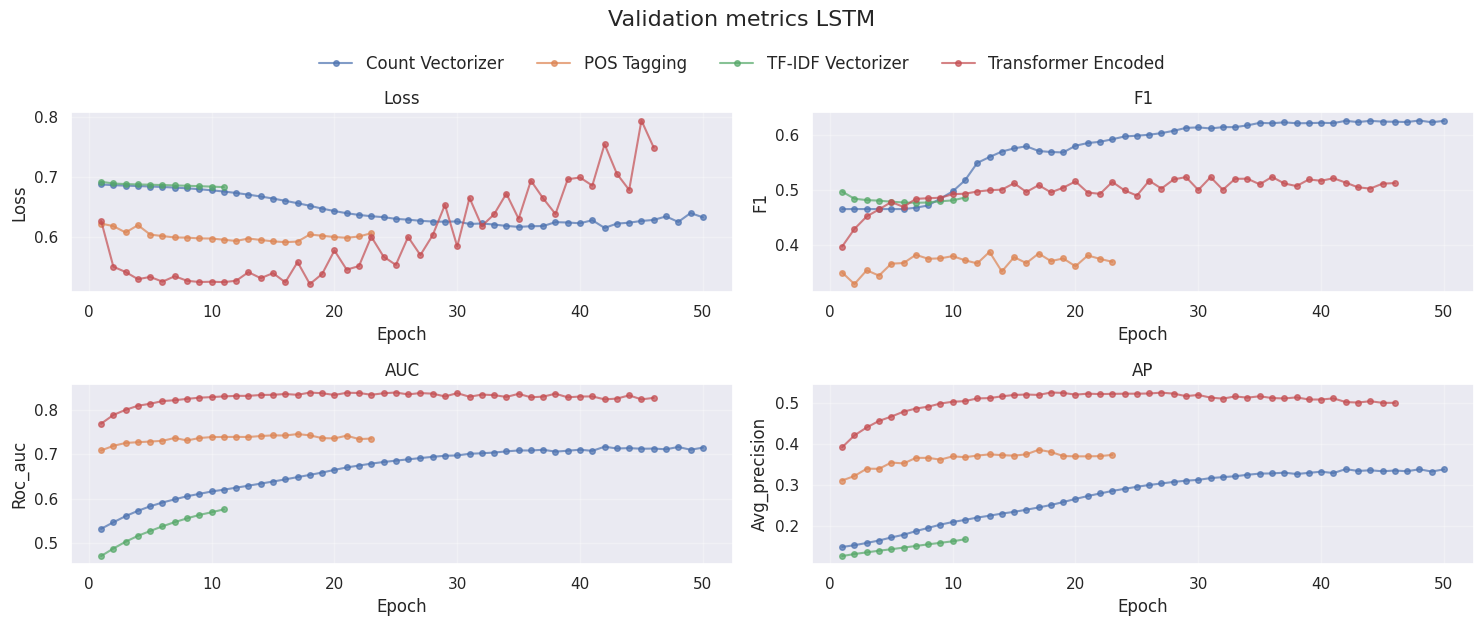

In [18]:
load_plot_rnn(file_paths_LSTM, savename = "pres_LSTM_plots" ,type = "LSTM") #

Rrsults
                                   model        f1 precision    recall  \
Count Vectorizer        Count Vectorizer  0.617604  0.613627  0.622269   
POS Tagging                  POS Tagging  0.381356  0.305146  0.508306   
TF-IDF Vectorizer      TF-IDF Vectorizer  0.623822  0.623373  0.624277   
Transformer Encoded  Transformer Encoded  0.507871  0.459184  0.568106   

                      roc_auc avg_precision      loss  
Count Vectorizer     0.706563      0.319894   0.62877  
POS Tagging          0.744637      0.374796  0.606695  
TF-IDF Vectorizer    0.708957      0.325901  0.628129  
Transformer Encoded  0.835794      0.509174   0.58333  


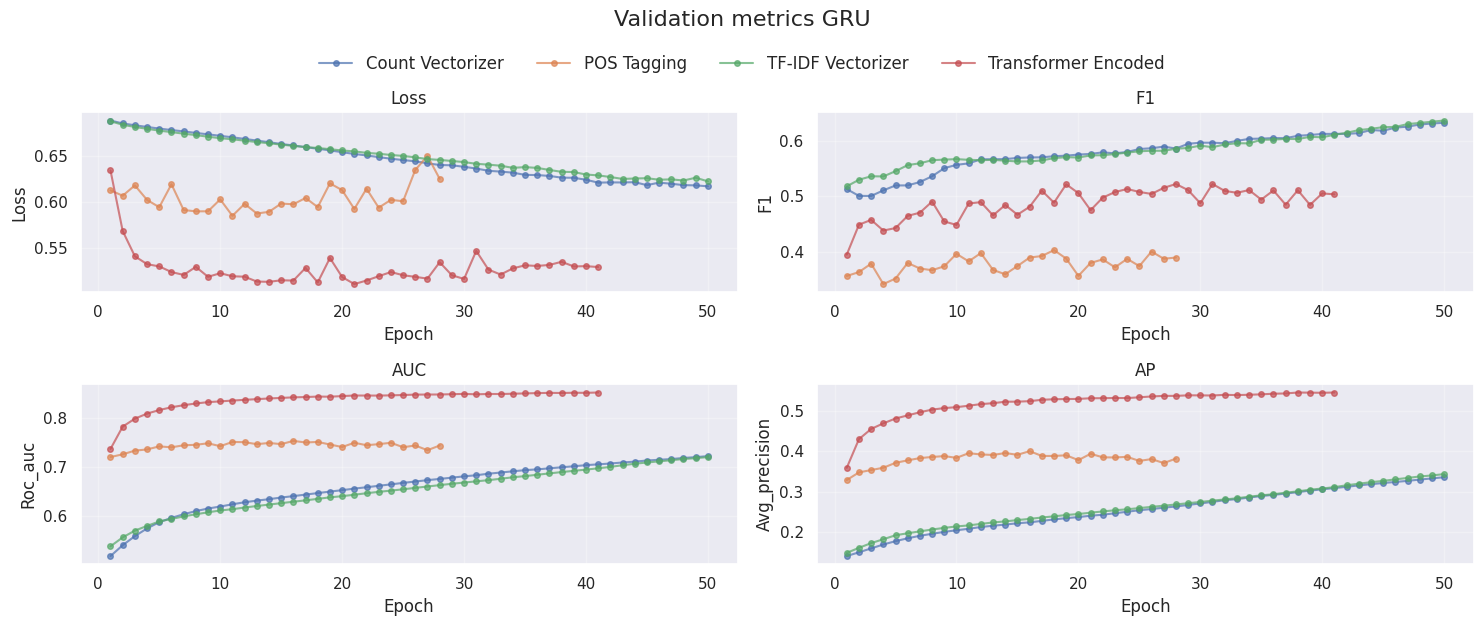

In [19]:
load_plot_rnn(file_paths_GRU, savename= "pres_GRU_plots" ,type = "GRU")

#### Movies

In [21]:
def load_plot_rnn(files_paths, savename = "", type = "GRU"):
    results_pres = {}
    for model_name, file_path in files_paths.items():
        with open(file_path, 'r') as f:
            results_pres[model_name] = json.load(f)

    training_history = {}
    validation_history = {}
    test_metrics = {}

    for model_name, data in results_pres.items():
        print(data)
        train_list = []
        val_list = []
        
        for epoch_data in data['history']:
            epoch = epoch_data['epoch']
            
            train_entry = {'epoch': epoch, 'model': model_name}
            train_entry.update(epoch_data['train'])
            train_list.append(train_entry)
            
            val_entry = {'epoch': epoch, 'model': model_name}
            val_entry.update(epoch_data['val'])
            val_list.append(val_entry)
        
        training_history[model_name] = pd.DataFrame(train_list)
        validation_history[model_name] = pd.DataFrame(val_list)
        
        test_entry = {'model': model_name}
        test_entry.update(data['test'])
        test_metrics[model_name] = test_entry

    train_combined = pd.concat(training_history.values(), ignore_index=True)
    val_combined = pd.concat(validation_history.values(), ignore_index=True)
    test_combined = pd.DataFrame(test_metrics).T

    print("Rrsults")
    print(test_combined)

    # Plot validation metrics comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 6))

    # metrics_val = ['loss', 'f1', 'precision', 'recall', 'roc_auc', 'avg_precision']
    # titles_val = ['Validation Loss', 'Validation F1', 'Validation Precision', 'Validation Recall', 'Validation AUC', 'Validation AP']
    metrics_val = ['loss', 'f1', 'roc_auc', "accuracy"]
    titles_val = ['Loss', 'F1', 'AUC',  "Accuracy" ]

    for idx, (ax, metric, title) in enumerate(zip(axes.flat, metrics_val, titles_val)):
        for model_name in validation_history.keys():
            df = validation_history[model_name]
            ax.plot(df['epoch'], df[metric], marker='o', label=model_name, alpha=0.7, markersize=4)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(title, fontsize=12)
        # ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=len(validation_history.keys()), fontsize=12, frameon=False)

    plt.suptitle(f"Validation metrics {type}", fontsize=16, y=1.04)
    plt.tight_layout(rect=[0, 0.03, 1, 0.88])

    plt.tight_layout()

    if savename:
        plt.savefig("images/" + savename + ".pdf", bbox_inches='tight')
    plt.show()

{'run_date': '2026-03-26 17:11:30', 'device': 'cuda', 'vectorizer': {'type': 'count', 'max_features': 10000, 'ngram_range': [1, 1]}, 'model_config': {'rnn_type': 'lstm', 'embed_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'learning_rate': 1e-05, 'weight_decay': 1e-05, 'early_stopping_patience': 10}, 'best_val_f1': 0.6596638655462185, 'epochs_trained': 11, 'history': [{'epoch': 1, 'train': {'f1': 0.6254335260115607, 'precision': 0.4963302752293578, 'recall': 0.8453125, 'roc_auc': 0.50796630859375, 'accuracy': 0.49375, 'avg_precision': 0.5123279317826006, 'loss': 0.6936963677406311}, 'val': {'f1': 0.6596638655462185, 'precision': 0.49683544303797467, 'recall': 0.98125, 'roc_auc': 0.474375, 'accuracy': 0.49375, 'avg_precision': 0.525476747080018, 'loss': 0.694450831413269}}, {'epoch': 2, 'train': {'f1': 0.6290040768782761, 'precision': 0.5013927576601671, 'recall': 0.84375, 'roc_auc': 0.47498291015625005, 'accuracy': 0.50234375, 'avg_precision': 0.47538191013853287, 'loss'

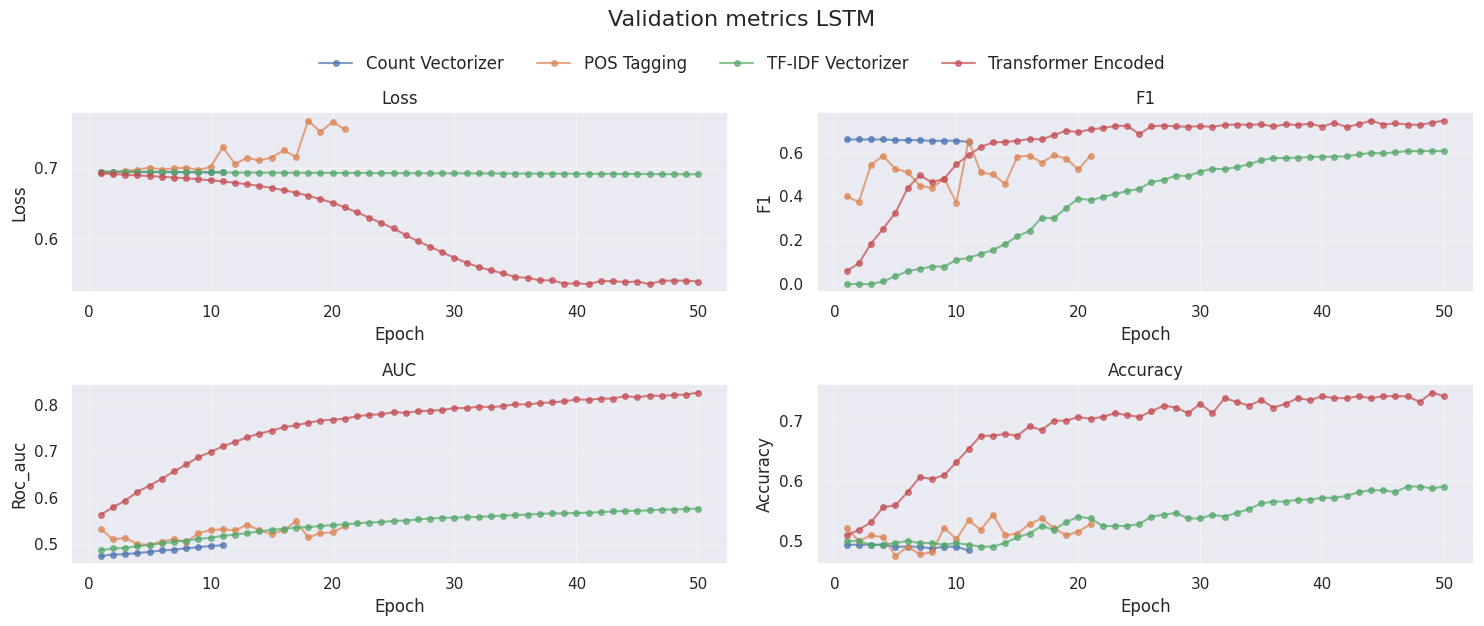

In [22]:
load_plot_rnn(file_paths_LSTM_movies, savename= "movies_LSTM_plots" ,type = "LSTM")

{'run_date': '2026-03-26 17:13:36', 'device': 'cuda', 'vectorizer': {'type': 'count', 'max_features': 10000, 'ngram_range': [1, 1]}, 'model_config': {'rnn_type': 'gru', 'embed_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'learning_rate': 1e-05, 'weight_decay': 1e-05, 'early_stopping_patience': 10}, 'best_val_f1': 0.6306306306306306, 'epochs_trained': 11, 'history': [{'epoch': 1, 'train': {'f1': 0.5892063492063492, 'precision': 0.49625668449197863, 'recall': 0.725, 'roc_auc': 0.509638671875, 'accuracy': 0.49453125, 'avg_precision': 0.5239898333993864, 'loss': 0.6959890127182007}, 'val': {'f1': 0.6306306306306306, 'precision': 0.49295774647887325, 'recall': 0.875, 'roc_auc': 0.40140625, 'accuracy': 0.4875, 'avg_precision': 0.4258466323026886, 'loss': 0.7020275980234146}}, {'epoch': 2, 'train': {'f1': 0.5960179833012202, 'precision': 0.5059978189749182, 'recall': 0.725, 'roc_auc': 0.5340698242187499, 'accuracy': 0.50859375, 'avg_precision': 0.5315722875060847, 'loss': 0.69

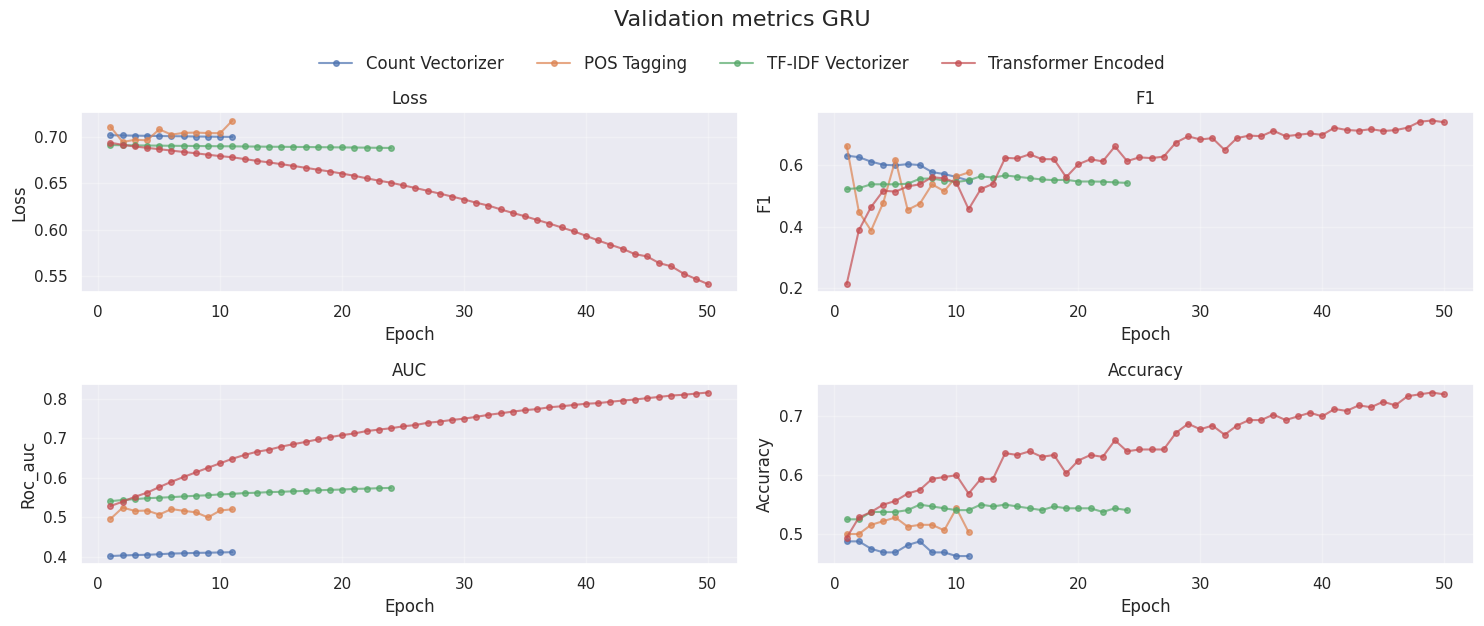

In [23]:
load_plot_rnn(file_paths_GRU_movies, savename= "movies_GRU_plots" ,type = "GRU")

### Plotting transformers

#### President

In [3]:
json_path = Path('results_json/pres_transformer_128_2e-05_camembert-base_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

In [4]:
def plot_trans(results, savename="", title=""):
    # get data
    train_metrics = []
    val_metrics = []

    for epoch_data in results['history']:
        epoch = epoch_data['epoch']

        train_row = {'epoch': epoch}
        train_row.update(epoch_data['train'])
        train_metrics.append(train_row)

        val_row = {'epoch': epoch}
        val_row.update(epoch_data['val'])
        val_metrics.append(val_row)

    df_train = pd.DataFrame(train_metrics)
    df_val = pd.DataFrame(val_metrics)

    test_metrics = results['test']

    print(df_train)
    print(df_val)
    print(test_metrics)

    # Plot F1 and Loss
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    sns.set_theme(style="darkgrid")

    metrics = ['loss', 'f1', 'avg_precision', 'roc_auc']
    titles = ['Loss ', 'F1 Score', 'Average Precision', 'AUC']

    for i, m in enumerate(metrics):
        ax = axes[i]
        ax.plot(df_train['epoch'], df_train[m], marker='o', label='Train', linewidth=2, color='steelblue')
        ax.plot(df_val['epoch'], df_val[m], marker='s', label='Validation', linewidth=2, color='coral')
        ax.axhline(test_metrics[m], color='green', linestyle='--', linewidth=2, label='Test', alpha=0.7)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(m.replace('_', ' ').title())
        ax.set_title(titles[i])
        # ax.legend()
        ax.grid(alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=len(results.keys()), fontsize=12, frameon=False)
    
    plt.suptitle(f"{title}", fontsize=16, y=1.04)
    plt.tight_layout(rect=[0, 0.03, 1, 0.88])

    plt.tight_layout()
    if savename:
        plt.savefig(savename + '.pdf', dpi=300, bbox_inches='tight')
    plt.show()

   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.687113   0.663365  0.749689  0.832869       0.508032  0.488525
1      2  0.776851   0.745176  0.831629  0.910062       0.694165  0.364854
2      3  0.829555   0.797255  0.877823  0.946840       0.807786  0.283019
3      4  0.863188   0.833700  0.903090  0.963953       0.859564  0.230037
4      5  0.892090   0.864314  0.927758  0.975688       0.906322  0.184775
5      6  0.917358   0.897189  0.940974  0.983889       0.934720  0.148970
6      7  0.891672   0.864281  0.926709  0.980501       0.919358  0.171160
7      8  0.935727   0.915107  0.959750  0.991258       0.958769  0.107416
8      9  0.948473   0.930499  0.968868  0.993369       0.971092  0.087096
9     10  0.959623   0.945654  0.974957  0.996146       0.979262  0.069424
   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.790006   0.804528  0.777408  0.898958       0.688335  0.414933
1      2  0.804784   0.78

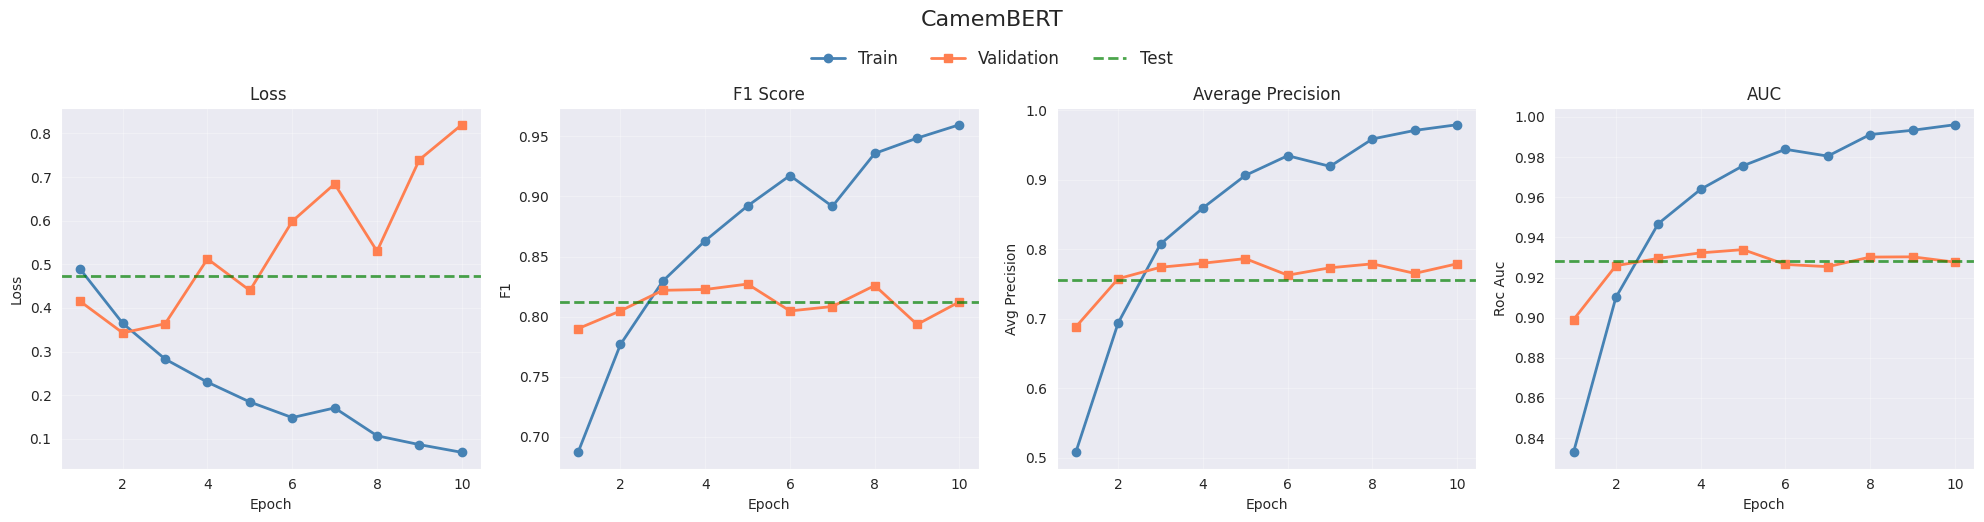

In [5]:
plot_trans(results, savename="images/pres_transf_camembert_20ep_128ml", title="CamemBERT")

In [9]:
json_path = Path('results_json/pres_transformer_128_2e-05_almanach_camemberta-base_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.709293   0.683033  0.767569  0.853371       0.549932  0.459579
1      2  0.815982   0.782732  0.868278  0.938667       0.783328  0.303018
2      3  0.880157   0.854497  0.912697  0.968198       0.887627  0.210699
3      4  0.911011   0.887976  0.938793  0.981554       0.931667  0.157814
4      5  0.936001   0.916973  0.957878  0.988514       0.956637  0.118044
5      6  0.952481   0.937063  0.969617  0.992918       0.973974  0.086084
6      7  0.963476   0.950932  0.977096  0.995071       0.981564  0.067772
7      8  0.969107   0.958006  0.981028  0.996478       0.985874  0.057630
   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.792789   0.781427  0.805780  0.916670       0.703297  0.378054
1      2  0.824421   0.821308  0.827627  0.938763       0.781957  0.343404
2      3  0.830267   0.834747  0.825964  0.935764       0.786721  0.361214
3      4  0.793811   0.90

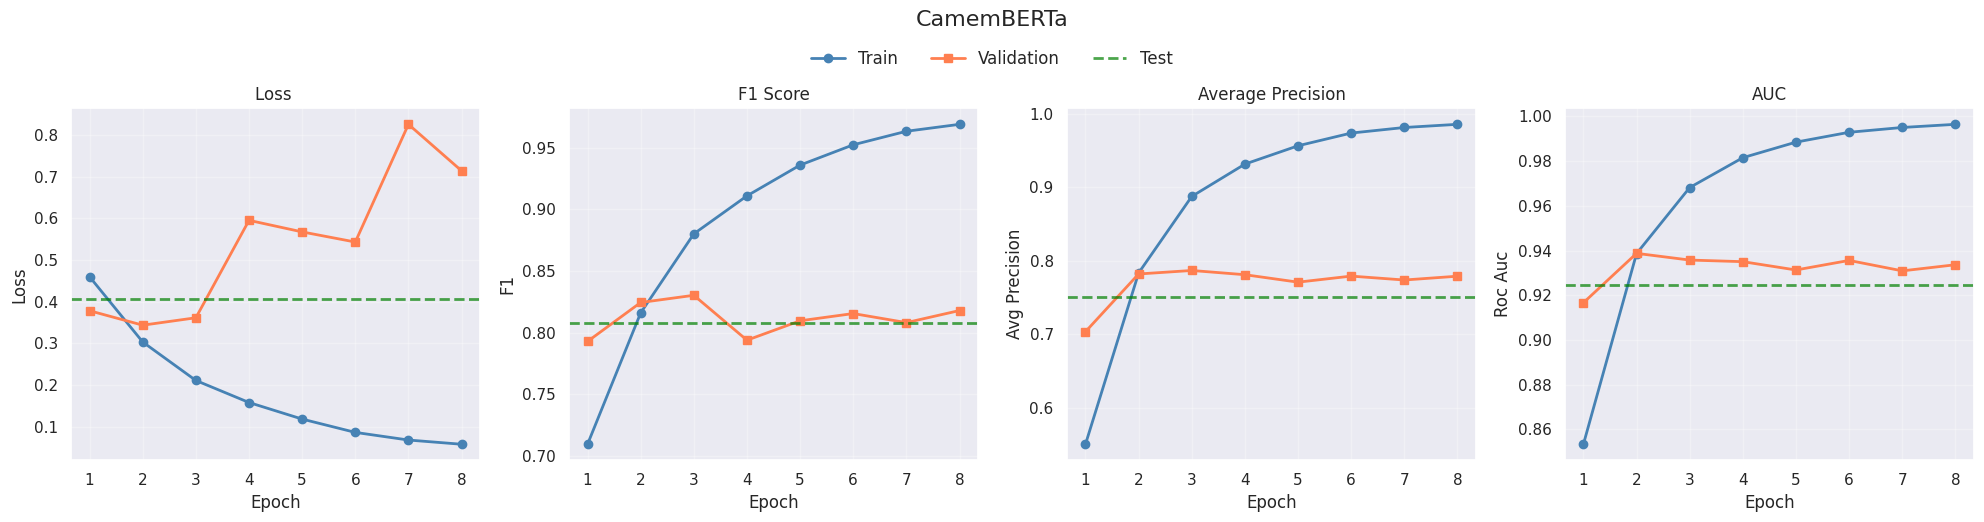

In [11]:
plot_trans(results, savename="images/pres_transf_camembertA_20ep_128ml", title="CamemBERTa")

   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.455969   0.360551  0.620066  0.813016       0.460359  0.526245
1      2  0.572633   0.453772  0.775862  0.895031       0.655322  0.408178
2      3  0.640156   0.525992  0.817615  0.925929       0.747029  0.341527
3      4  0.690293   0.587070  0.837557  0.941713       0.800439  0.303189
4      5  0.727784   0.630362  0.860823  0.953442       0.830159  0.268575
5      6  0.750825   0.658014  0.874117  0.961899       0.864940  0.240329
6      7  0.782656   0.693567  0.898006  0.967711       0.887446  0.217219
7      8  0.805896   0.720530  0.914209  0.975600       0.909616  0.187079
8      9  0.833744   0.766736  0.913585  0.979147       0.918305  0.171400
9     10  0.842115   0.771988  0.926257  0.981279       0.929683  0.162604
   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.600471   0.569196  0.635382  0.879708       0.648950  0.459233
1      2  0.646489   0.62

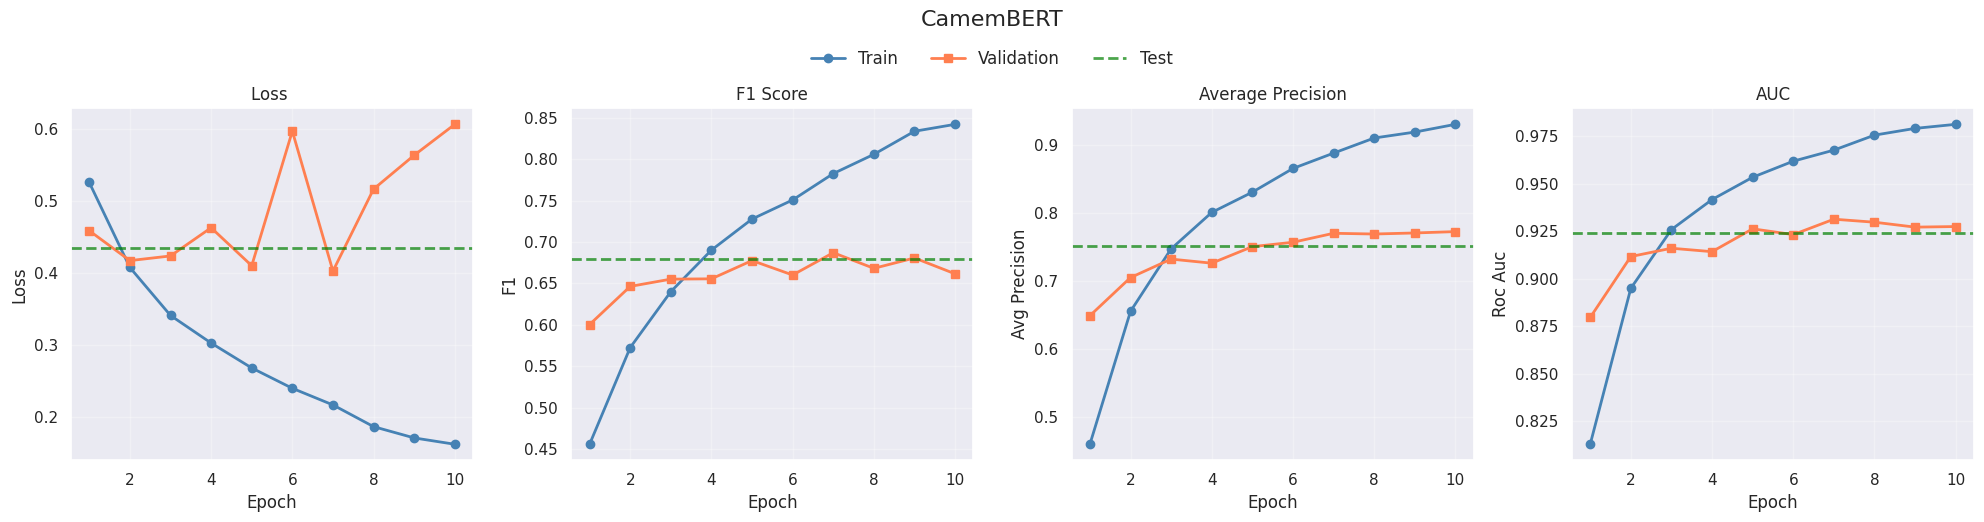

In [ ]:
# old president
json_path = Path('results_json/results_transformer.json')
with open(json_path, 'r') as f:
    results = json.load(f)
plot_trans(results, savename="images/pres_transf_camembertA_10ep_512ml", title="CamemBERT")

#### Movies

In [4]:
def plot_trans(results, savename="", title=""):
    # get data
    train_metrics = []
    val_metrics = []

    for epoch_data in results['history']:
        epoch = epoch_data['epoch']

        train_row = {'epoch': epoch}
        train_row.update(epoch_data['train'])
        train_metrics.append(train_row)

        val_row = {'epoch': epoch}
        val_row.update(epoch_data['val'])
        val_metrics.append(val_row)

    df_train = pd.DataFrame(train_metrics)
    df_val = pd.DataFrame(val_metrics)

    test_metrics = results['test']

    print(df_train)
    print(df_val)
    print(test_metrics)

    # Plot F1 and Loss
    metrics = ['loss', 'f1', "accuracy", 'roc_auc']
    titles = ['Loss ', 'F1 Score', "Accuracy",  'AUC']

    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))
    sns.set_theme(style="darkgrid")

    for i, m in enumerate(metrics):
        ax = axes[i]
        ax.plot(df_train['epoch'], df_train[m], marker='o', label='Train', linewidth=2, color='steelblue')
        ax.plot(df_val['epoch'], df_val[m], marker='s', label='Validation', linewidth=2, color='coral')
        ax.axhline(test_metrics[m], color='green', linestyle='--', linewidth=2, label='Test', alpha=0.7)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(m.replace('_', ' ').title())
        ax.set_title(titles[i])
        # ax.legend()
        ax.grid(alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=len(results.keys()), fontsize=12, frameon=False)
    
    plt.suptitle(f"{title}", fontsize=16, y=1.04)
    plt.tight_layout(rect=[0, 0.03, 1, 0.88])

    plt.tight_layout()
    if savename:
        plt.savefig(savename + '.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    epoch        f1  precision    recall   roc_auc  avg_precision  accuracy  \
0       1  0.649186   0.770386  0.560937  0.789614       0.788269  0.696875   
1       2  0.880821   0.889952  0.871875  0.929766       0.921889  0.882031   
2       3  0.907975   0.891566  0.925000  0.951436       0.942884  0.906250   
3       4  0.949099   0.951334  0.946875  0.969858       0.971933  0.949219   
4       5  0.957265   0.952087  0.962500  0.979036       0.979032  0.957031   
5       6  0.967843   0.971654  0.964063  0.984038       0.985961  0.967969   
6       7  0.965079   0.980645  0.950000  0.983394       0.985700  0.965625   
7       8  0.971743   0.976341  0.967187  0.996035       0.996524  0.971875   
8       9  0.977147   0.985692  0.968750  0.991740       0.989986  0.977344   
9      10  0.981221   0.982759  0.979688  0.990776       0.989585  0.981250   
10     11  0.990610   0.992163  0.989062  0.995735       0.997509  0.990625   
11     12  0.994544   0.992224  0.996875  0.998328  

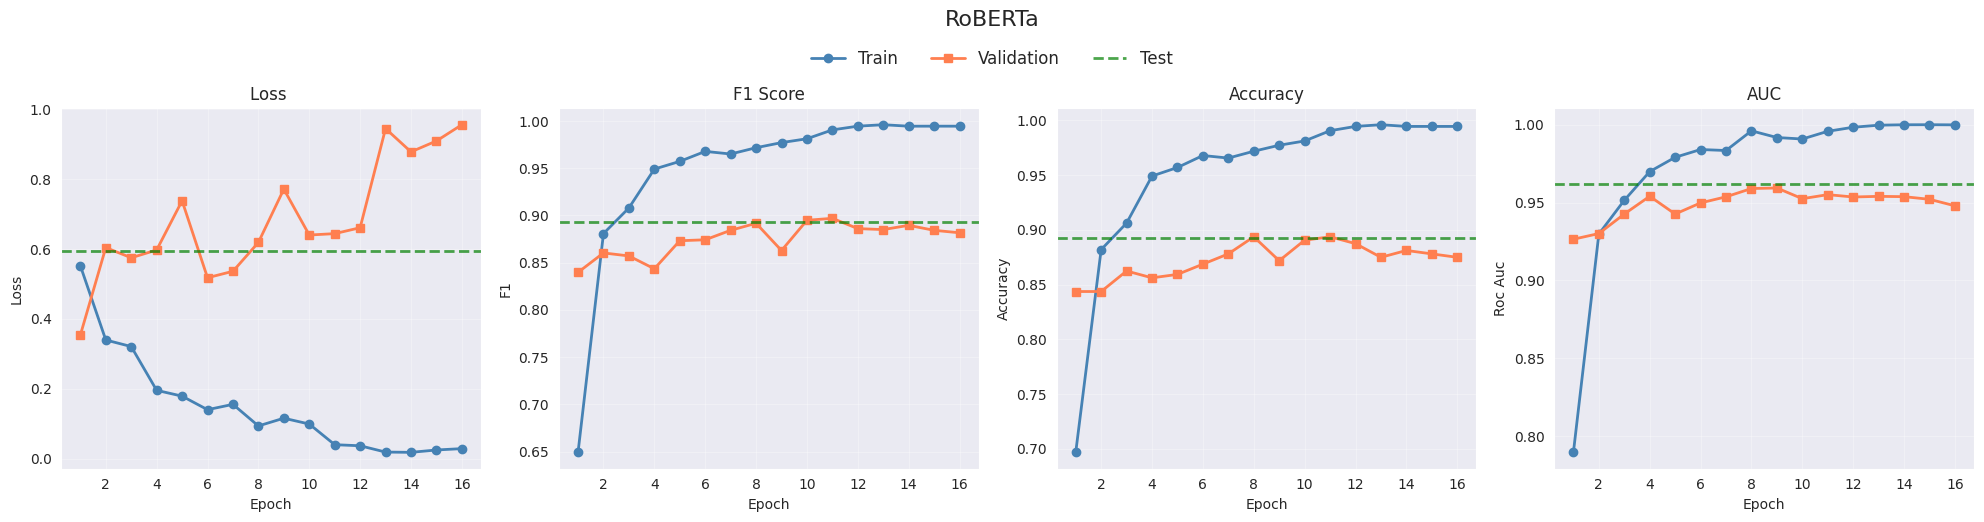

In [5]:
json_path = Path('results_json/movies_transformer_512_2e-05_FacebookAI_roberta-base_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

plot_trans(results, savename="images/movies_transformer_512_2e-05_roberta1", title="RoBERTa")

    epoch        f1  precision    recall   roc_auc  avg_precision  accuracy  \
0       1  0.581771   0.496141  0.703125  0.498193       0.493700  0.494531   
1       2  0.495458   0.525394  0.468750  0.533000       0.533550  0.522656   
2       3  0.709892   0.758437  0.667188  0.804539       0.784463  0.727344   
3       4  0.849294   0.853312  0.845313  0.897478       0.884741  0.850000   
4       5  0.866926   0.863566  0.870313  0.917612       0.909545  0.866406   
5       6  0.902682   0.885714  0.920312  0.946038       0.929955  0.900781   
6       7  0.919663   0.901049  0.939063  0.960596       0.940294  0.917969   
7       8  0.926011   0.904620  0.948438  0.970168       0.964013  0.924219   
8       9  0.936728   0.925305  0.948438  0.969958       0.949702  0.935937   
9      10  0.939347   0.934985  0.943750  0.979387       0.973157  0.939063   
10     11  0.958947   0.950845  0.967187  0.983174       0.983818  0.958594   
11     12  0.944795   0.953822  0.935937  0.982281  

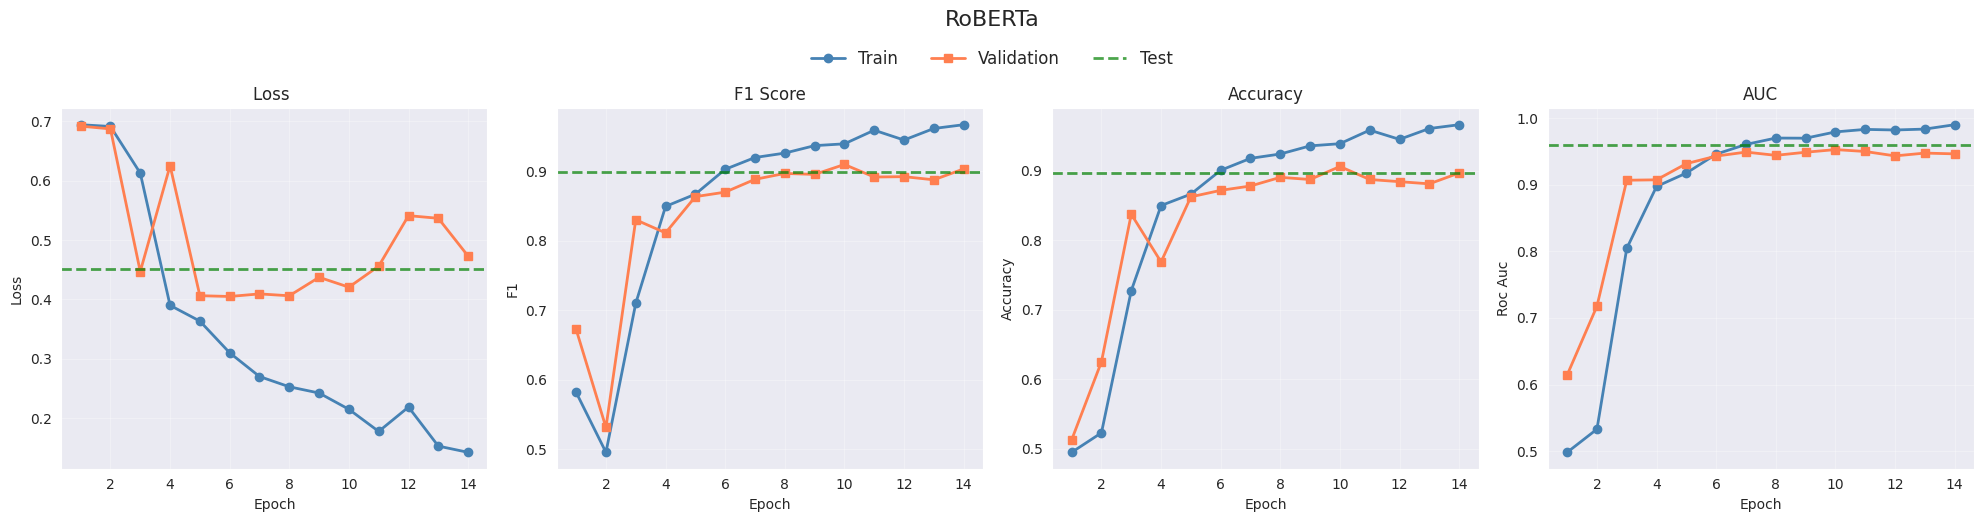

In [5]:
json_path = Path('results_json/movies_transformer_512_2e-06_FacebookAI_roberta-base_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

plot_trans(results, savename="images/movies_transformer_512_2e-06_roberta", title="RoBERTa")

### Plotting simple models grid search

In [ ]:
# for president the file was ran twice
dataset = "movies"

if dataset == "president":
    with open('results_json/model_test_results_20260324_004319.json', 'r') as f:
        ml_results_basic = json.load(f)

    # Load Linear SVM results
    with open('results_json/model_test_results_lin_scv_20260324_122136.json', 'r') as f:
        ml_results_linear_svm = json.load(f)

else:
    with open('results_json/movies_simple_model_20260328_145125.json', 'r') as f:
        ml_results_basic = json.load(f)

#    # Load Linear SVM results
#    with open('results_json/model_test_results_movies_lin_scv_20260324_122136.json', 'r') as f:
#        ml_results_linear_svm = json.load(f)

In [13]:
ml_basic_df = pd.DataFrame([
    {
        'prep': r['prep'],
        'vectorizer': r['vectorizer'],
        'model': r['model'],
        'status': r['status'],
        **{f'cv_{k}': v for k, v in r.get('cv_metrics', {}).items()},
        **{f'test_{k}': v for k, v in r.get('test_metrics', {}).items()}
    }
    for r in ml_results_basic
])

ml_combined = ml_basic_df.copy() 

if dataset == "president":
    ml_linear_svm_df = pd.DataFrame([
        {
            'prep': r['prep'],
            'vectorizer': r['vectorizer'],
            'model': 'linear_svm', 
            'status': r['status'],
            **{f'cv_{k}': v for k, v in r.get('cv_metrics', {}).items()},
            **{f'test_{k}': v for k, v in r.get('test_metrics', {}).items()}
        }
        for r in ml_results_linear_svm
    ])

    ml_basic_success = ml_basic_df[ml_basic_df['status'] == 'success'].copy() # svc failed heree
    ml_combined = pd.concat([ml_basic_success, ml_linear_svm_df], ignore_index=True)
print(ml_combined)

     prep     vectorizer                model   status     cv_f1  cv_f1_std  \
0   Prep2  count_unigram          naive_bayes  success  0.799784   0.019700   
1   Prep2  count_unigram  logistic_regression  success  0.834327   0.029279   
2   Prep2  count_unigram           linear_svm  success  0.812703   0.028396   
3   Prep2  count_unigram              svm_rbf  success  0.780006   0.007996   
4   Prep2  count_unigram        random_forest  success  0.813471   0.004096   
5   Prep2   count_bigram          naive_bayes  success  0.812160   0.011840   
6   Prep2   count_bigram  logistic_regression  success  0.832937   0.022156   
7   Prep2   count_bigram           linear_svm  success  0.820762   0.022357   
8   Prep2   count_bigram              svm_rbf  success  0.795896   0.016246   
9   Prep2   count_bigram        random_forest  success  0.823005   0.023229   
10  Prep2  tfidf_unigram          naive_bayes  success  0.791337   0.025328   
11  Prep2  tfidf_unigram  logistic_regression  succe

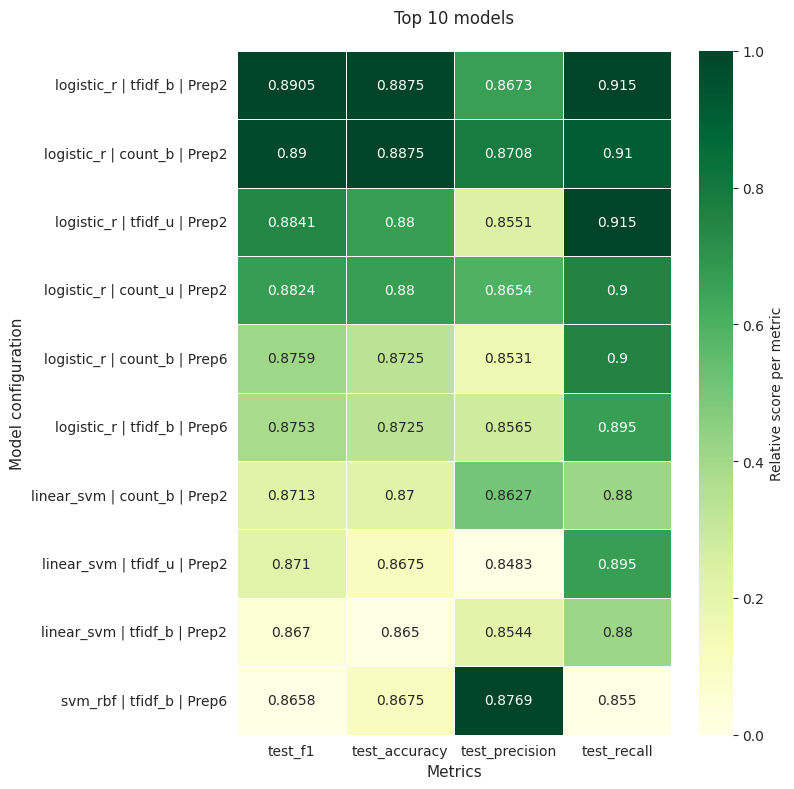

In [15]:
# plotting the top 10 models by f1

# Select key metrics and normalize
if dataset == "president":
    top_10 = ml_combined.nlargest(10, 'test_f1_macro')
    metrics = ['test_f1_macro', 'test_roc_auc', 'test_avg_precision']
    heatmap_data = top_10[['model', 'vectorizer', 'prep'] + metrics].copy()
else:
    top_10 = ml_combined.nlargest(10, 'test_f1')
    metrics = ['test_f1', 'test_accuracy', 'test_precision', 'test_recall'] 
    heatmap_data = top_10[['model', 'vectorizer', 'prep'] + metrics].copy()

# Create display labels
heatmap_data['config'] = (heatmap_data['model'].str[:10] + ' | ' + 
                          heatmap_data['vectorizer'].str[:7] + ' | ' + 
                          heatmap_data['prep'].str[:11])

# Normalize metrics to 0-1 range for better visualization
normalized_data = heatmap_data[metrics].copy()
for col in metrics:
    col_min = normalized_data[col].min()
    col_max = normalized_data[col].max()
    if col_max > col_min:
        normalized_data[col] = (normalized_data[col] - col_min) / (col_max - col_min)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(normalized_data.set_index(heatmap_data['config']), 
            annot=heatmap_data[metrics].round(4).values, 
            fmt='g', cmap='YlGn', cbar_kws={'label': 'Relative score per metric'}, ax=ax, linewidths=0.5) #YlOrRd
ax.set_title('Top 10 models', fontsize=12, pad=20)
ax.set_xlabel('Metrics',  fontsize=11)
ax.set_ylabel('Model configuration', fontsize=11)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.savefig("images/movies_top_10_models_heatmap.pdf", dpi=300)
plt.show()